In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('../data/Superstore.csv')

#print("\nMissing Values in Data:")
#print(data.isnull().sum())

#print("\nDuplicate Rows in Data:")
#print(data.duplicated().sum())

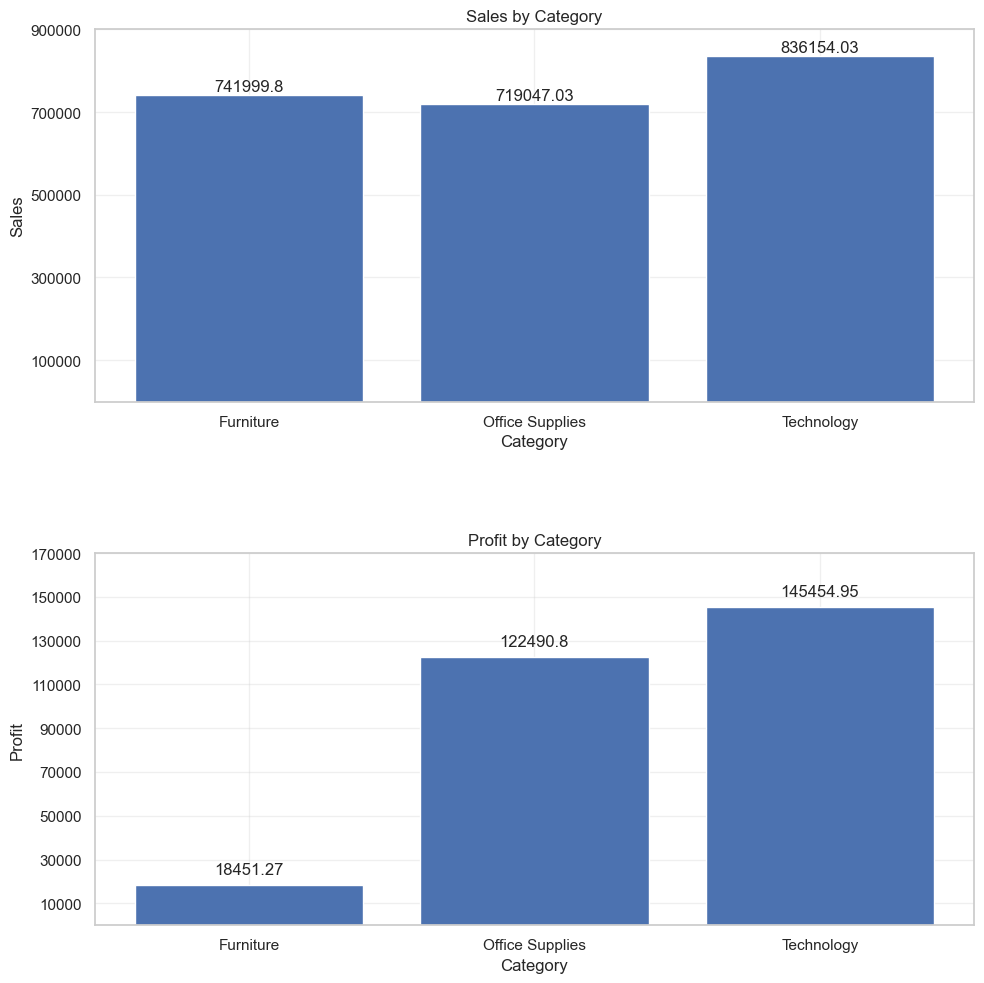


1. Sales by Category

- Technology has the highest sales.
- Office Supplies has the lowest sales.

2. Profit by Category

- Technology generates the highest profit.
- Furniture has lower profit compared to its sales.

Insight:
- Technology is the best-performing category in both sales and profit.



In [93]:
# Analysis 1
# Sales by Category

sales_data = data.groupby("Category")['Sales'].sum()
profit_data = data.groupby('Category')['Profit'].sum()

# Modern Matplotlib - oop
fig, axes = plt.subplots(2,1, figsize=(10,10))

axes[0].bar(sales_data.index,sales_data)
axes[0].set_title('Sales by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Sales')
axes[0].set_yticks(range(100000, int(max(sales_data)) + 100000, 200000))

for i in range(len(sales_data.index)):
    axes[0].text(sales_data.index[i],
                 sales_data.iloc[i]+10000,
                 round(sales_data.iloc[i],2),
            ha='center')

axes[0].grid(alpha=0.3)

# Analysis 2
# Profit by Category

axes[1].bar(profit_data.index,profit_data)
axes[1].set_title("Profit by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Profit")
axes[1].set_yticks(range(10000, int(max(profit_data)) + 30000, 20000))

for i in range(len(profit_data)):
    axes[1].text(profit_data.index[i],
                 profit_data.iloc[i]+5000,
                 round(profit_data.iloc[i],2),
                 ha='center')

axes[1].grid(alpha=0.3)

fig.tight_layout(h_pad=5) # space between graphs
#plt.subplots_adjust(hspace=0.5)  # space between graphs

plt.savefig('../images/sales_&_profit_by_category.png', bbox_inches="tight")
plt.show()

print("""
1. Sales by Category

- Technology has the highest sales.
- Office Supplies has the lowest sales.

2. Profit by Category

- Technology generates the highest profit.
- Furniture has lower profit compared to its sales.

Insight:
- Technology is the best-performing category in both sales and profit.
""")

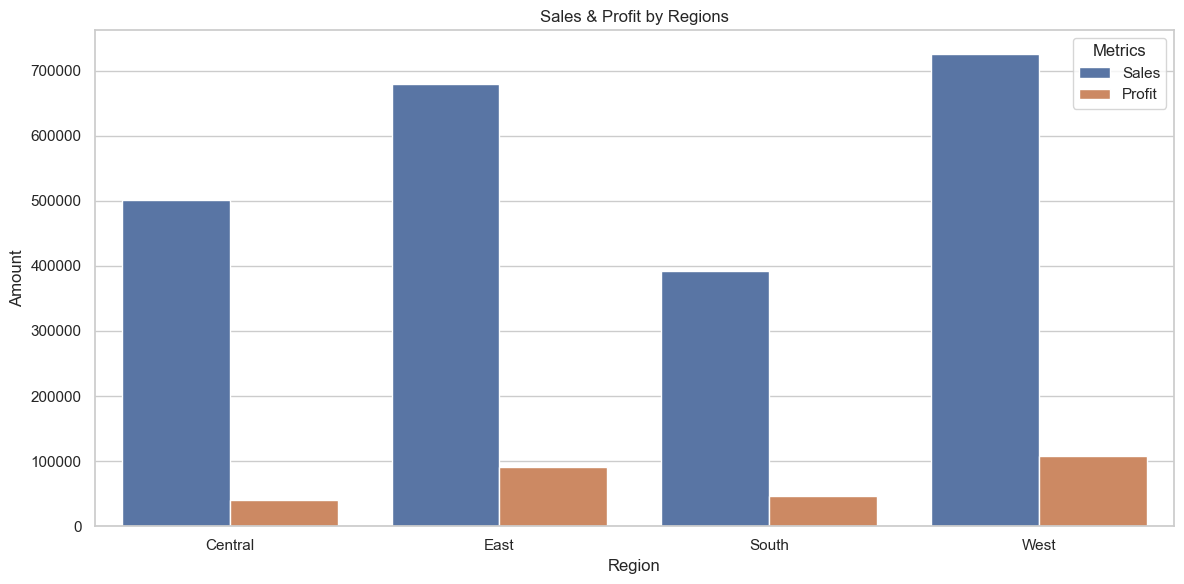


3. Sales & Profit by Region

- West has the highest sales and profit.
- South has the lowest sales and profit.
- Higher sales generally result in higher profit.

Insight:
- West is the best-performing region.
- South has growth opportunities and needs improvement.



In [94]:
# Analysis 3
# Sales & Profit by Regions

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

region_data = data.groupby('Region')[['Sales','Profit']].sum().reset_index()

region_data = region_data.melt(
    id_vars='Region',
    value_vars=['Sales','Profit'],
    var_name = 'Metrics',
    value_name = 'Amount'
)

sns.barplot(
    data=region_data,
    x='Region',
    y='Amount',
    hue='Metrics',
)

plt.title("Sales & Profit by Regions")
plt.tight_layout()
plt.show()

print("""
3. Sales & Profit by Region

- West has the highest sales and profit.
- South has the lowest sales and profit.
- Higher sales generally result in higher profit.

Insight:
- West is the best-performing region.
- South has growth opportunities and needs improvement.
""")

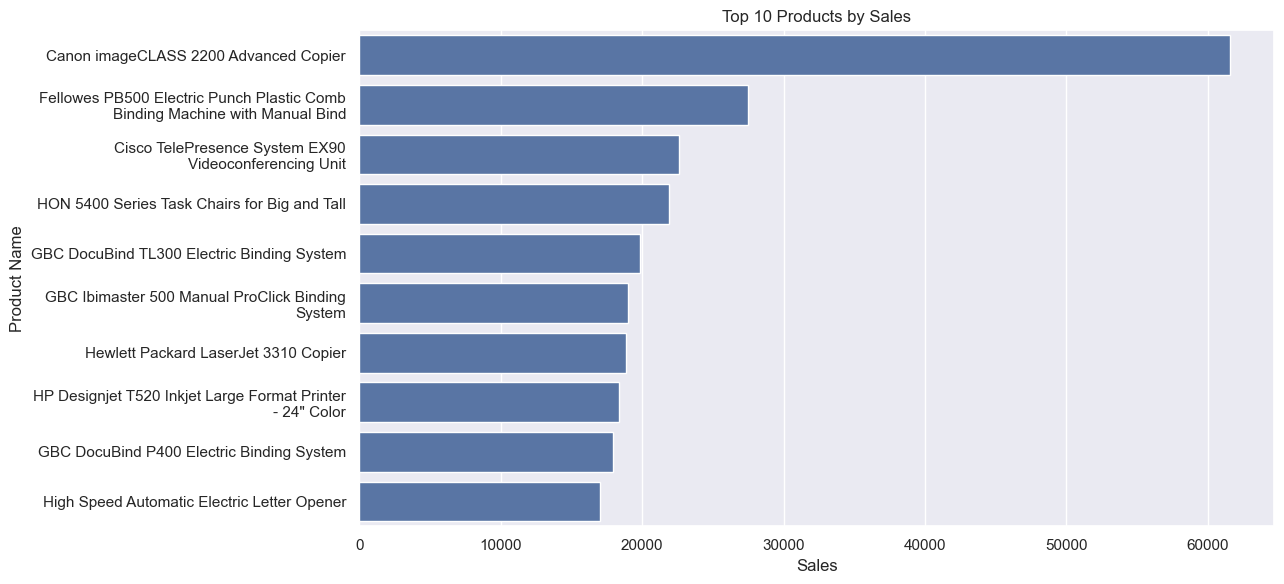


4. Top 10 Products by Sales

- Canon imageCLASS 2200 Advanced Copier has the highest sales.
- The remaining top products have significantly lower sales.
- Most top-selling products are from Office Supplies and Technology.

Insight:
- The Canon imageCLASS 2200 Advanced Copier is the best-selling product.
- High-value products contribute significantly to overall sales.



In [103]:
# Analysis 4
# Top 10 Products by Sales

from textwrap import fill

sns.set_theme(style="darkgrid")
plt.figure(figsize=(13,6))

products = (data.groupby('Product Name')['Sales'].sum()
    .sort_values(ascending=False)
    .head(10).reset_index())

# Wrap product names after 45 characters
products['Product Name'] = products['Product Name'].apply(lambda x: fill(x, width=45))

sns.barplot(data=products,
           x='Sales',
           y='Product Name')

plt.title('Top 10 Products by Sales')
plt.tight_layout()
plt.savefig('../images/top_10_products_by_sales.png')
plt.show()

print("""
4. Top 10 Products by Sales

- Canon imageCLASS 2200 Advanced Copier has the highest sales.
- The remaining top products have significantly lower sales.
- Most top-selling products are from Office Supplies and Technology.

Insight:
- The Canon imageCLASS 2200 Advanced Copier is the best-selling product.
- High-value products contribute significantly to overall sales.
""")